<a href="https://colab.research.google.com/github/jfimbett/LLMsInFinance/blob/main/comparable_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparable Selection for Valuation

# Why do we need to find comparable firms? The overall distribution is very noisy

### How does the distribution of valuation ratios look like?

100%|██████████| 502/502 [02:31<00:00,  3.32it/s]


array([[<Axes: title={'center': 'P/E'}>]], dtype=object)

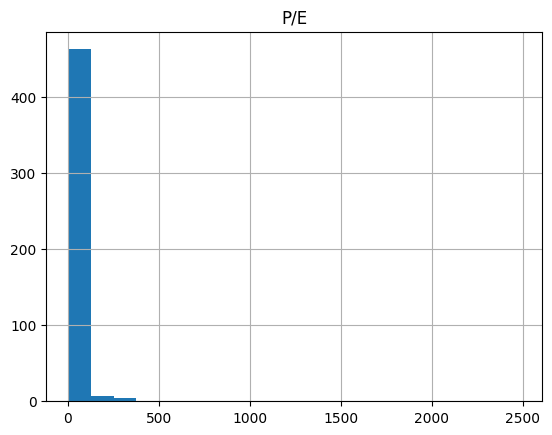

In [1]:
#!/usr/bin/env python3
"""
Compute the trailing Price‑to‑Earnings (P/E) ratio for every current S&P 500 constituent.

Requirements:
    pip install pandas yfinance lxml

Usage:
    python sp500_pe.py

Notes:
    • Trailing EPS may be None or ≤ 0 for some tickers; those observations are skipped.
    • The script downloads ticker metadata one‑by‑one via yfinance, which can take a few
      minutes (≈ 5‑7 min on a typical home connection).  For a faster batch approach,
      see the yfinance download_bulk utility or the official Yahoo Finance API.
"""

import pandas as pd
import yfinance as yf
from tqdm import tqdm


def get_sp500_tickers() -> list[str]:
    """Return the list of current S&P 500 ticker symbols from Wikipedia."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    table = pd.read_html(url, header=0)[0]
    return table["Symbol"].tolist()


def compute_pe_ratios(tickers: list[str]) -> pd.DataFrame:
    """Fetch price & EPS for each ticker and calculate its trailing P/E."""
    records: list[dict] = []
    for symbol in tqdm(tickers):
        try:
            tkr = yf.Ticker(symbol)
            info = tkr.info
            price = info.get("regularMarketPrice")
            eps = info.get("trailingEps")
            if price is not None and eps and eps > 0:
                records.append({"Ticker": symbol, "P/E": price / eps})
        except Exception as e:
            # Network hiccup or missing field – skip and continue
            continue
    return (
        pd.DataFrame(records)
        .set_index("Ticker")
        .sort_values("P/E")
        .round(2)
    )



tickers = get_sp500_tickers()
pe_df = compute_pe_ratios(tickers)

# histogram
pe_df.hist(bins=20)




In [2]:
company_ciks = {
    "GM":    "0001467858",   # General Motors Co.
    "F":     "0000037996",   # Ford Motor Co.
    "RIVN":  "0001874178",   # Rivian Automotive, Inc.
    "LCID":  "0001811210",   # Lucid Group, Inc.
    "NIO":   "0001736541",   # NIO Inc.
    "NKLA":  "0001731289",   # Nikola Corporation
    "FSR":   "0001720990",   # Fisker Inc.
    "CHPT":  "0001777393",   # ChargePoint Holdings, Inc.
    "EVGO":  "0001821159",   # EVgo Inc.
    "BYDDY": "0001445162",   # BYD Company Ltd. (U.S. ADR)
}

In [4]:
from openai import OpenAI

from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))


response = client.embeddings.create(
    input="This is some text",
    model="text-embedding-3-small"
)

print(response.data[0].embedding)

[-0.003125505056232214, 0.041273582726716995, 0.0006799799739383161, 0.010149241425096989, -0.028079569339752197, -0.047393884509801865, 0.03241606429219246, 0.011010389775037766, 0.00479397876188159, -0.01802259311079979, 0.020113952457904816, 0.017161445692181587, -0.03518403694033623, -0.006262543611228466, 0.06464759260416031, 0.009564891457557678, -0.02760286256670952, 0.003840565448626876, -0.02086745575070381, 0.06310983002185822, 0.03380005061626434, 0.028233345597982407, 0.004836267326027155, 0.011971492320299149, 0.0173921100795269, -0.004317271988838911, 0.015961989760398865, 0.004636358004063368, 0.023066459223628044, -0.0363834947347641, 0.03244682028889656, -0.0429958775639534, 0.008649921976029873, -0.04982355237007141, -0.01090274564921856, 0.017607396468520164, 0.03192397952079773, 0.024189027026295662, -0.0022047690581530333, -0.029232891276478767, 0.010564438067376614, -0.015723636373877525, 0.024865642189979553, -0.016315674409270287, -0.0346919521689415, 0.00299287

In [8]:
!pip install requests
import requests
from pathlib import Path
import tiktoken
from typing import List, Dict, Tuple, Any, Union

import math
from typing import List

def split_into_chunks(
    text: str,
    n_chunks: int,
    overlap_frac: float = 0.10,
) -> List[str]:
    """
    Split `text` into `n_chunks`, each overlapping the next by `overlap_frac`.

    Parameters
    ----------
    text : str
        The full raw text you want to slice up.
    n_chunks : int
        Desired number of chunks (≥ 2).
    overlap_frac : float, default 0.10
        Fraction of each chunk that should overlap with its successor.
        Must satisfy 0 ≤ overlap_frac < 1.

    Returns
    -------
    List[str]  – `n_chunks` items; the last chunk may be shorter if the
                 math doesn't land exactly on the final character.
    """
    if not (0 <= overlap_frac < 1):
        raise ValueError("overlap_frac must be in the half-open interval [0, 1).")
    if n_chunks < 2:
        return [text]

    L = len(text)
    # Effective step forward each time (non-overlapping part)
    step = L / n_chunks
    overlap = overlap_frac * step
    stride = step - overlap

    # Round to integers for slicing
    step_i   = math.ceil(step)
    stride_i = max(1, math.ceil(stride))

    chunks = []
    start = 0
    for _ in range(n_chunks):
        end = start + step_i
        chunks.append(text[int(start):int(end)])
        start += stride_i
        if start >= L:
            break

    # If rounding left us short of the target count, pad last chunk(s)
    while len(chunks) < n_chunks:
        chunks.append("")
    return chunks

MODEL = "text-embedding-3-large"  # max 8000 tokens

def latest_10k_or_10q_text(
    cik: str | int,
    *,
    user_agent: str = "QuickFilingGrabber/2.0 (jfimbett@gmail.com)",
    return_url: bool = False,
) -> Union[str, Tuple[str, str]]:
    """
    Download the newest 10-K or 10-Q for `cik` and return the **raw text**.

    Parameters
    ----------
    cik : str | int
        Company CIK (with or without leading zeros).
    user_agent : str, optional
        REQUIRED by the SEC – include contact info in parentheses.
    return_url : bool, default False
        If True, also return the SEC master-file URL.

    Returns
    -------
    str                    – if return_url is False.
    (str, str) tuple       – if return_url is True (second element is the URL).

    Raises
    ------
    ValueError      – if no recent 10-K/10-Q exists.
    requests.HTTPError – for any HTTP failure.
    """
    cik_raw = str(int(cik))           # strip leading zeros from user input
    cik10   = cik_raw.zfill(10)       # pad back to 10 digits for the API

    # 1) Pull the recent-filings feed -----------------------------------------------
    feed_url = f"https://data.sec.gov/submissions/CIK{cik10}.json"
    hdrs     = {"User-Agent": user_agent, "Accept-Encoding": "gzip, deflate"}
    recent   = requests.get(feed_url, headers=hdrs, timeout=30).json()["filings"]["recent"]

    # 2) Find the first 10-K or 10-Q -------------------------------------------------
    for form, acc in zip(recent["form"], recent["accessionNumber"]):
        if form in {"10-K", "10-Q"}:
            acc_no_dash = acc.replace("-", "")
            txt_url = (
                f"https://www.sec.gov/Archives/edgar/data/{int(cik_raw)}/"
                f"{acc_no_dash}/{acc}.txt"
            )
            raw_txt = requests.get(txt_url, headers=hdrs, timeout=60).text
            break
    else:
        raise ValueError("No recent 10-K or 10-Q found in the feed.")

    return (raw_txt, txt_url) if return_url else raw_txt



def count_tokens(text: str, model: str = "gpt-4o-mini") -> int:
    """
    Return the number of tokens `text` would occupy for the given OpenAI model.
    Falls back to the GPT-4/3.5 tokenizer ('cl100k_base') if the model name
    isn't recognised by tiktoken.
    """
    try:
        enc = tiktoken.encoding_for_model(model)
    except KeyError:
        enc = tiktoken.get_encoding("cl100k_base")
    return len(enc.encode(text))


# ---------------------------------------------------------------------------
# DEMO: Tesla, Inc. (CIK 0001318605)
# ---------------------------------------------------------------------------

text, url = latest_10k_or_10q_text("0001318605", return_url=True)

chunks = split_into_chunks(text, n_chunks=700, overlap_frac=0.05)

lenghts = [count_tokens(chunk) for chunk in chunks]

# maximum number of tokens
print(f"Maximum number of tokens: {max(lenghts)}")



Maximum number of tokens: 7974


## What if the number of chunks is not enough for every single company?

Dynamic batching

In [9]:
from functools import lru_cache
import tiktoken

# ------------------------------------------------------------------
# tiny helpers
# ------------------------------------------------------------------
enc = tiktoken.get_encoding("cl100k_base")        # any model-compatible vocab

def count_tokens(text: str) -> int:
    """Token‐count with a tiny LRU cache so we don't double-count the same chunk."""
    return len(enc.encode(text))

@lru_cache(maxsize=128)
def _split_cached(text_id: int, n: int, ov: float):
    """Wrap your own split_into_chunks() so identical calls aren't recomputed."""
    return split_into_chunks(_TEXT_STORE[text_id], n_chunks=n, overlap_frac=ov)

# ------------------------------------------------------------------
# main routine
# ------------------------------------------------------------------
def optimal_n_chunks(
    text: str,
    max_tokens_per_chunk: int = 8_000,
    overlap_frac: float = 0.05,
) -> int:
    """
    Smallest n such that max( token_count(chunk) ) <= max_tokens_per_chunk.
    Uses exponential + binary search (O(log n) splits instead of O(n)).
    """

    # quick exit ─ whole doc already fits
    if count_tokens(text) <= max_tokens_per_chunk:
        return 1

    # Stash the text once so we can memo-split by (text_id, n, ov)
    text_id = id(text)
    _TEXT_STORE = {}
    _TEXT_STORE[text_id] = text

    # 1) Exponential search for an upper bound that works
    n = 2
    while True:
        chunks = split_into_chunks(text, n_chunks=n, overlap_frac=overlap_frac)
        if max(count_tokens(c) for c in chunks) <= max_tokens_per_chunk:
            break
        n *= 2                                    # double until it's enough

    # n now passes; n//2 fails. Do a classic binary search in (n//2, n]
    lo = n // 2 + 1                               # first known failing n
    hi = n                                        # first known passing n
    best = hi

    while lo <= hi:
        mid = (lo + hi) // 2
        chunks = split_into_chunks(text, n_chunks=mid, overlap_frac=overlap_frac)
        if max(count_tokens(c) for c in chunks) <= max_tokens_per_chunk:
            best = mid                            # record a tighter answer
            hi = mid - 1                          # and look for an even smaller one
        else:
            lo = mid + 1                          # need more chunks

    del _TEXT_STORE[text_id]                      # tidy up
    return best

# ------------------------------------------------------------------
# example use
# ------------------------------------------------------------------
text, url = latest_10k_or_10q_text("0001318605", return_url=True)

n_chunks = optimal_n_chunks(text, max_tokens_per_chunk=8_000, overlap_frac=0.05)
chunks   = split_into_chunks(text, n_chunks=n_chunks, overlap_frac=0.05)
lengths  = [count_tokens(c) for c in chunks]

print(f"{n_chunks=}, max(tokens)={max(lengths)}")   # sanity check


n_chunks=699, max(tokens)=7999


In [10]:
# Embed each chunk
embeddings = []
for chunk in tqdm(chunks):
    resp = client.embeddings.create(model=MODEL, input=chunk)
    embeddings.append(resp.data[0].embedding)

# You now have a list of vectors, one per chunk
print(f"{len(embeddings)=}, dimension={len(embeddings[0])}")


100%|██████████| 699/699 [05:25<00:00,  2.15it/s]

len(embeddings)=699, dimension=3072


In [11]:
import numpy as np

# embeddings is your list[ list[float] ]
embeddings_np = np.array(embeddings, dtype=np.float32)   # shape: (num_chunks, dim)

# 1. Average across rows (chunks)
doc_vec = embeddings_np.mean(axis=0)                     # shape: (dim,)

# 2. Re-normalize to unit length (cosine-sim friendly)
doc_vec /= np.linalg.norm(doc_vec)

print(f"Document vector dimension: {doc_vec.shape[0]}, norm: {np.linalg.norm(doc_vec):.3f}")


Document vector dimension: 3072, norm: 1.000


In [14]:
# we do the same for every single comparable

ompany_ciks = {
    "GM":    "0001467858",   # General Motors Co.
    "F":     "0000037996",   # Ford Motor Co.
    "RIVN":  "0001874178",   # Rivian Automotive, Inc.
    "LCID":  "0001811210",   # Lucid Group, Inc.
    "NIO":   "0001736541",   # NIO Inc.
    "NKLA":  "0001731289",   # Nikola Corporation
    "FSR":   "0001720990",   # Fisker Inc.
    "CHPT":  "0001777393",   # ChargePoint Holdings, Inc.
    "EVGO":  "0001821159",   # EVgo Inc.
    "BYDDY": "0001445162",   # BYD Company Ltd. (U.S. ADR)
}

all_embeddings = []
for ticker, cik in tqdm(company_ciks.items()):
  text, url = latest_10k_or_10q_text(cik, return_url=True)
  print(f"Computing optimal amount of chunks for {cik}")
  n_chunks = optimal_n_chunks(text, max_tokens_per_chunk=8_000, overlap_frac=0.05)
  chunks   = split_into_chunks(text, n_chunks=n_chunks, overlap_frac=0.05)

  embeddings = []
  for chunk in tqdm(chunks):
      resp = client.embeddings.create(model=MODEL, input=chunk)
      embeddings.append(resp.data[0].embedding)

  embeddings_np = np.array(embeddings, dtype=np.float32)
  doc_vec_ = embeddings_np.mean(axis=0)
  doc_vec_ /= np.linalg.norm(doc_vec_)
  all_embeddings.append(doc_vec_)

# cosine similarity across doc_vec and all the ones in all_embeddings
from sklearn.metrics.pairwise import cosine_similarity
similarity_scores = cosine_similarity(np.array([doc_vec]), np.array(all_embeddings))
similarity_scores

